# Chapter 0 — The thesis

`pdum.dsl` is a Python DSL compiler framework: a numba-like `@jit` workflow with
Julia-like **type-keyed caching**. This book is its documentation, written
**bottom-up**: one chapter per implementation step, each chapter exposing the
internals built in that step — not just the API. Run every cell; poke at
everything. Source references point into `src/pdum/dsl/`; the design rationale
lives in `docs/design/010_proposed-architecture.md`, and the vocabulary in
[`GLOSSARY.md`](GLOSSARY.md).

This chapter contains **no new code**. It states the one idea the whole system
is built around, and demonstrates it with the frozen proof of concept
(Milestone 0, preserved at `pdum.dsl_reference` — see `reference/README.md`),
so you can see the destination before we lay the first brick.

## The thesis

A closure is **(code identity, typed environment, environment values)** — and
compilation should be keyed on the *types*, never the *values*:

| Phase | When | What happens |
|---|---|---|
| **A — capture** | at `@jit` decoration (every closure rebuild) | read the code object + captured values → summarize their **types**. No compilation, ever. |
| **B — call** | at draw/call time | cache key = (code identity, env types, arg types, …). **Miss**: compile once. **Hit**: re-marshal the current values and launch. |

The payoff is the cost model: building a GPU pipeline costs ~1–10 ms;
rewriting its uniform buffer costs ~0.1 ms. If the cache keys on types, a
render loop that rebuilds its closure every frame with *new parameter values*
pays the 0.1 ms path — moving a knob is a buffer write, not a recompile.
That's the entire product: **the loop stays hot**.

Nobody else's default works this way: numba freezes captured values into the
compiled code as constants, and JAX bakes closure captures into the trace —
in both, `closure(5)` and `closure(6)` are different compiled programs. (The
receipts are in `docs/design/022_closure_specialization.md` and
`docs/design/research/R4-jax.md`.)

In [1]:
# The frozen proof of concept, kept importable precisely so this chapter can run it.
from pdum.dsl_reference import builtins, jit


def disk(cx, cy, radius):
    @jit(kind="fragment")  # M0's own kind vocabulary — the frozen reference keeps its names
    def shader():
        x, y = builtins.FragCoord.xy
        dx = x - cx
        dy = y - cy
        d2 = dx * dx + dy * dy
        return (1.0, 0.5, 0.0) if d2 < radius * radius else (0.05, 0.05, 0.12)

    return shader


h = disk(320.0, 240.0, 70.0)
print("the Handle:          ", h)
print("its structural type: ", h.fntype)
print("its captured values: ", h.env)

the Handle:           Handle[fragment](Fn<disk.<locals>.shader>(f64, f64, f64), env=['cx', 'cy', 'radius'])
its structural type:  Fn<disk.<locals>.shader>(f64, f64, f64)
its captured values:  {'cx': 320.0, 'cy': 240.0, 'radius': 70.0}


`@jit` did **not** compile anything — phase A only read the closure's code
object and cells. The `Handle` holds the two halves the thesis separates: a
structural *type* (into cache keys) and the captured *values* (never in a
key; destined for the uniform buffer).

In [2]:
h5, h6 = disk(100.0, 100.0, 50.0), disk(300.0, 200.0, 50.0)
print("different values?    ", h5.env != h6.env)
print("same TYPE?           ", h5.fntype == h6.fntype, "  <- one compilation, shared")

h_int = disk(100.0, 100.0, 50)  # radius is an int this time
print("int radius same type?", h_int.fntype == h5.fntype, " <- a capture changed TYPE: its own compilation")

different values?     True
same TYPE?            True   <- one compilation, shared
int radius same type? False  <- a capture changed TYPE: its own compilation


In [3]:
import math

HAS_GPU = True
try:
    from pdum.dsl_reference.webgpu import Context

    ctx = Context()
    drawer = ctx.offscreen_drawer(size=(320, 240))
except (ImportError, RuntimeError) as e:  # no adapter / no wgpu — anything else should FAIL the chapter
    HAS_GPU = False
    print(f"no GPU adapter available ({type(e).__name__}); skipping the live demo")

if HAS_GPU:
    for k in range(120):  # rebuild the closure EVERY frame with fresh values
        t = k * 0.05
        drawer.update(disk(160 + 80 * math.cos(t), 120 + 60 * math.sin(t), 45.0))
        drawer.show()
    print(f"frames={drawer.uniform_writes}  compiles={drawer.compile_count}")
    assert drawer.compile_count == 1, "the thesis, asserted"

frames=120  compiles=1


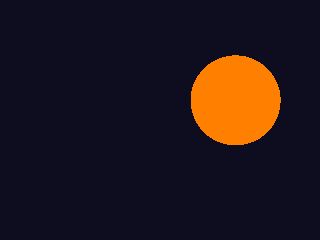

In [4]:
def rgba_png(pixels: bytes, w: int, h: int) -> bytes:
    """Raw RGBA bytes -> PNG, stdlib only (15 lines, because this repo adds no deps lightly)."""
    import struct
    import zlib

    def chunk(tag, data):
        body = tag + data
        return struct.pack(">I", len(data)) + body + struct.pack(">I", zlib.crc32(body))

    ihdr = struct.pack(">IIBBBBB", w, h, 8, 6, 0, 0, 0)
    raw = b"".join(b"\x00" + pixels[y * w * 4 : (y + 1) * w * 4] for y in range(h))
    return b"\x89PNG\r\n\x1a\n" + chunk(b"IHDR", ihdr) + chunk(b"IDAT", zlib.compress(raw)) + chunk(b"IEND", b"")


if HAS_GPU:
    from IPython.display import Image, display

    w, hh = drawer.target.size
    display(Image(data=rgba_png(drawer.target.read_pixels(), w, hh)))

## What M0 got wrong — and what the rebuild does about it

The proof of concept proved the thesis but earned a redesign
(`docs/design/010_proposed-architecture.md`, built from the research corpus in
`docs/design/research/`). The load-bearing faults, each now a structural fix:

| M0 fault | The rebuild's answer |
|---|---|
| `flatten()` re-parsed and re-lowered ASTs **every frame** just to collect values | a precompiled per-entry extractor; the hot path is key build + pack + launch, no AST/IR objects exist on it |
| captured uniforms were **scalars only** (no `center=(cx, cy)`) | a marshaling layer: one logical value → N physical slots, planned once from types |
| the core **imported the WGSL backend's tables** | five registration surfaces on one explicit Registry; backends are capability records |
| the expression-tree IR **could not grow** (no `if`/`for`, arrays, transforms) | one frozen `Node`/`Region` micro-IR, three region ops, everything else is rewrite rules |
| backend params (target format) **missing from the cache key** | a two-tier cache with a key-completeness perturbation test |
| nothing could hold a capture value *wrongly* — by discipline only | the IR has **no field that can hold a value**; the anti-pattern is unrepresentable |

## The map of the book

| Chapter | Step builds | Kernel modules |
|---|---|---|
| **ch00 — The thesis** *(you are here)* | scaffolding, budgets, this map | — |
| ch01 — Types are values | the type lattice, `typeof`, fingerprints | `types.py`, `valuekind.py` |
| ch02 — What a closure is | phase-A capture | `capture.py` |
| ch03 — One compile per signature | the two-tier cache (thesis proven with dummy artifacts) | `cache.py` |
| ch04 — Pipelines are values | combinator syntax + roles (satellite: zero kernel edits) | `combinators.py` |
| ch05 — Programs are values | the IR | `ir.py`, `ops.py`, `printer.py` |
| ch06 — Everything is a rule | the rewrite engine | `rewrite.py` |
| ch07 — Source to IR | lowering | `lower.py` + rule packs |
| ch08 — One value, N parameters | marshaling | `pack.py` |
| ch09 — End to end on the CPU | the Python backend + the hot path | `backends/python.py`, `api.py` |
| ch10 — The GPU and the seam | the WGSL backend; **M1 complete** | `backends/wgsl/` |
| ch11 — The five surfaces | batteries, records, registry | `stdlib/` |
| ch12+ | arrays/loops/C, vmap/jvp, grad, more backends, units, … | per plan |

Budgets are architecture: the kernel is CI-capped at 1150 counted lines
(`scripts/loc_budget.py`), and "a new capability lands with zero kernel edits"
will itself become a CI test. Every chapter reports the running total.

**Next:** [Chapter 1 — Types are values](ch01-types-are-values.ipynb).